# Flowsheets as Data

A difflow flowsheet is normally only expressible as Python: the code that builds it *is*
the model. That is fine inside a script, but it means a flowsheet cannot be saved, diffed,
sent to a colleague, or opened by anything that did not import the module that built it.

The obstacle is not the file format. It is that one field holds **code**. A reactor's rate
law is a Python function, and a function cannot be written to a file, shown in a form, or
reasoned about by a tool that did not define it:

$$r_j = A_j \, T^{n_j} \exp\!\left(\frac{-E_{a,j}}{RT}\right) \prod_i C_i^{\nu^f_{ij}}$$

Mass-action kinetics is *data* — a table of coefficients — even though it is usually
written as code. This notebook follows one flowsheet through what becomes possible once
it is: a catalog, a file, a script, a local editor, and a page anyone can open with
nothing installed.

The through-line worth watching is that **every representation must give the same
answer**. A format that reloads into a plausible-but-different model would be worse than
no format at all, so each section ends by re-solving and comparing.

## 1. Setup

In [1]:
import jax
import jax.numpy as jnp

jax.config.update("jax_enable_x64", True)

import json
import numpy as np
import matplotlib.pyplot as plt

from difflow import (
    CSTR, CSTRParams, Flowsheet, Unit,
    catalog, codegen, describe_operation, make_stream,
    mass_action_kinetics, publish, serialize, sweep, SweepAxis,
)
from difflow.serialize import SerializationError
from difflow.codegen import CodegenError

# palette: categorical slots 1-2, plus muted ink and grid
BLUE, ORANGE = "#2a78d6", "#eb6834"
INK, INK_SOFT, GRID = "#0b0b0b", "#52514e", "#e4e2de"

R_GAS = 8.314462618
SPECIES = ["A", "B"]
FEED = make_stream({"A": 1.0, "B": 0.0}, T=350.0, P=101325.0)

## 2. A flowsheet only Python can express

A first-order reaction $A \to B$, with the rate law written the usual way: as a function.
`rate_fn` takes the concentration vector, the temperature, and a parameter dict, and
returns one rate per reaction.

In [2]:
def rate_fn(C, T, params):
    """A -> B, first order in A. C is keyed by species name."""
    k = params["A"] * jnp.exp(-params["Ea"] / (R_GAS * T))
    return jnp.array([k * C["A"]])


coded = Flowsheet(species_order=SPECIES)
coded.add_feed("feed", FEED)
coded.add_unit(Unit("reactor", CSTR(CSTRParams(
    V=1.0,
    molar_density=1000.0,
    rate_fn=rate_fn,
    stoich=jnp.array([[-1.0], [1.0]]),
    rate_params={"A": 1.0e3, "Ea": 40_000.0},
    species_order=SPECIES,
)), ["feed"], ["out"]))

streams = coded.solve()
print(f"F_B out = {float(streams['out']['F_B']):.6f} mol/s")

F_B out = 0.517517 mol/s


It solves, and it differentiates. But it cannot leave the process it was built in:

In [3]:
for write, name in [(serialize.to_dict, "serialize.to_dict"),
                    (codegen.to_python, "codegen.to_python")]:
    try:
        write(coded)
    except (SerializationError, CodegenError) as exc:
        print(f"{name}: {type(exc).__name__}")
        print(f"  {str(exc).splitlines()[0][:88]}...")

serialize.to_dict: SerializationError
  unit 'reactor' field 'rate_fn' holds a callable ('rate_fn'), which cannot be written to ...
codegen.to_python: CodegenError
  unit 'reactor'.rate_fn holds a callable ('rate_fn') that does not record how it was buil...


Note that it **refuses** rather than dropping the field. A file that silently lost a
reactor's rate law would reload into a model that still ran, still looked plausible, and
computed something else. That failure is much worse than the error.

## 3. The same reactor, built from data

`mass_action_kinetics` takes the same information as a table. Stoichiometry comes from the
`reactants` and `products` keys — `equation` is a label for reports, and is *not* parsed,
so a reaction that names neither side is refused rather than quietly reacting nothing.

In [4]:
kin = mass_action_kinetics([
    {
        "equation": "A -> B",
        "reactants": {"A": 1.0},
        "products": {"B": 1.0},
        "rate_params": {"A": 1.0e3, "Ea": 40_000.0, "n": 0.0},
    },
], SPECIES)

print(kin.summary())

1 reaction(s) over 2 species (A, B); reverse mode: error

equation                                     A      n  Ea (kJ/mol)       K_eq
------------------------------------------------------------------------------
A -> B                                    1000   0.00        40.00          -


In [5]:
def build(V=1.0):
    """The same flowsheet, with the rate law built from data."""
    fs = Flowsheet(species_order=SPECIES)
    fs.add_feed("feed", FEED)
    fs.add_unit(Unit("reactor", CSTR(CSTRParams(
        V=V, molar_density=1000.0, **kin.params_kwargs()
    )), ["feed"], ["out"]))
    return fs


declarative = build()
print(f"hand-written : {float(coded.solve()['out']['F_B']):.12f}")
print(f"from data    : {float(declarative.solve()['out']['F_B']):.12f}")

hand-written : 0.517517465674


from data    : 0.517517465674


Identical to the last digit — as it must be. The declarative form is not an approximation
of the coded one; it is the same arithmetic, assembled from a table instead of typed.

`params_kwargs()` supplies four fields at once (`rate_fn`, `stoich`, `rate_params`,
`species_order`), because they have to agree with each other and deriving three of them
from the fourth is what keeps them consistent.

## 4. What a form could fill in

With the rate law expressible as data, a tool can ask what a unit *takes* without
instantiating one. `difflow.catalog` derives that by introspection — ports from the
`__call__` signature, parameters from `dataclasses.fields`, equations from the class
attribute — so it cannot drift from the code.

In [6]:
spec = describe_operation("CSTR")
print(f"{spec.name}: {spec.ports.n_inlets} in -> {spec.ports.n_outlets} out")
print(f"required: {spec.required_parameters()}")
print(f"holds code: {spec.callable_parameters()}\n")

print(f"{'parameter':<22}{'type':<34}{'required'}")
for p in spec.parameters[:8]:
    print(f"{p.name:<22}{str(p.type)[:32]:<34}{p.required}")

CSTR: 1 in -> 1 out
required: ['V', 'rate_fn', 'stoich', 'rate_params', 'species_order']
holds code: ['rate_fn', 'eos', 'H_mix_fn', 'K_eq_fn']

parameter             type                              required
V                     float | jax.jaxlib._jax.Array     True
rate_fn               typing.Callable[[dict[str, jax.j  True
stoich                <class 'jax.jaxlib._jax.Array'>   True
rate_params           <class 'dict'>                    True
species_order         list[str]                         True
dH_rxn                jax.jaxlib._jax.Array | None      False
T_damping             <class 'float'>                   False
molar_density         float | None                      False


In [7]:
schemas = catalog()
declarative_ops = [n for n, s in schemas.items() if s.is_declarative]
print(f"{len(declarative_ops)} of {len(schemas)} registered operations are declarative")
print("the rest hold code:")
for name, s in sorted(schemas.items()):
    if not s.is_declarative:
        print(f"  {name:<22}{', '.join(s.callable_parameters())}")

68 of 75 registered operations are declarative
the rest hold code:
  CSTR                  rate_fn, eos, H_mix_fn, K_eq_fn
  ContinuousBioreactor  kinetic_fn
  FedBatchBioreactor    kinetic_fn
  FedBatchReactor       rate_fn
  GasPFR                rate_fn
  PFR                   rate_fn
  SemiBatchReactor      rate_fn


The handful that are not declarative are the reactors, and always because of the rate law
— which is exactly what section 3 removes. Everything else a palette would offer is
already data.

## 5. A file format

With no callables left, the flowsheet is JSON.

In [8]:
serialize.save(declarative, "reactor.json")
document = json.loads(open("reactor.json").read())

print(f"format_version {document['format_version']}, "
      f"written by difflow {document['difflow_version']}")
print(f"units: {[u['name'] for u in document['units']]}")
print("\nthe reactor's stored parameters:")
for key, value in document["units"][0]["params"].items():
    rendered = json.dumps(value)
    print(f"  {key:<26}{rendered[:52]}{'...' if len(rendered) > 52 else ''}")

format_version 1, written by difflow 0.1.0
units: ['reactor']

the reactor's stored parameters:
  V                         1.0
  rate_fn                   {"$callable": {"factory": "mass_action_kinetics", "a...
  stoich                    {"$array": [[-1.0], [1.0]]}
  rate_params               {"A": {"$array": [1000.0]}, "n": {"$array": [0.0]}, ...
  species_order             ["A", "B"]
  dH_rxn                    null
  T_damping                 0.3
  molar_density             1000.0
  eos                       null
  reaction_phase            "vapor"
  H_mix_fn                  null
  K_eq_fn                   null
  outlet_volumetric_basis   false


`K_eq` is `Infinity`: an irreversible reaction has no finite equilibrium constant, and the
rate law divides the reverse term by it, so the reverse contribution is exactly zero. It
is worth noticing because JSON has no literal for infinity — Python writes the bare token
`Infinity`, which a browser's `JSON.parse` rejects. Anything shipping this document over
HTTP has to encode it, which is what `difflow.gui` does.

In [9]:
reloaded = serialize.load("reactor.json")
print(f"saved    : {float(declarative.solve()['out']['F_B']):.12f}")
print(f"reloaded : {float(reloaded.solve()['out']['F_B']):.12f}")

saved    : 0.517517465674


reloaded : 0.517517465674


## 6. Back to source

A file is enough for a tool, but not for a person. An editor you can only *enter* is worse
than none: the moment you want something the palette does not offer, you have to be able
to drop into Python and keep going.

In [10]:
source = codegen.to_python(declarative)
print(source)

"""Flowsheet generated by difflow 0.1.0.

Edit freely --- this is ordinary difflow code.
"""

from difflow import (
    CSTR,
    CSTRParams,
    Flowsheet,
    Unit,
    make_stream,
    mass_action_kinetics,
)

kinetics_reactor = mass_action_kinetics(reactions=[{'equation': 'A -> B', 'reactants': {'A': 1.0}, 'products': {'B': 1.0}, 'rate_params': {'A': 1000.0, 'Ea': 40000.0, 'n': 0.0}}], species_order=['A', 'B'], reverse='error', orders=None)

fs = Flowsheet(species_order=['A', 'B'], default_flow=0.01, default_T=300.0, default_P=101325.0)

fs.add_feed('feed', make_stream({'A': 1.0, 'B': 0.0}, T=350.0, P=101325.0))

fs.add_unit(Unit('reactor', CSTR(CSTRParams(**kinetics_reactor.params_kwargs(), V=1.0, dH_rxn=None, T_damping=0.3, molar_density=1000.0, eos=None, reaction_phase='vapor', H_mix_fn=None, K_eq_fn=None, outlet_volumetric_basis=False)), ['feed'], ['out']))


if __name__ == "__main__":
    streams = fs.solve()
    for name, stream in streams.items():
        print(name, stream)

The rate law is hoisted into its own `mass_action_kinetics(...)` statement and splatted
back, rather than inlined — which is how the docs write it, and how someone editing the
script would want it. Inlining would bury the reactor under the derived stoichiometry and
order matrices in one unreadable line.

It is ordinary difflow code, so it runs:

In [11]:
namespace = {}
exec(compile(source, "<generated>", "exec"), namespace)

print(f"original  : {float(declarative.solve()['out']['F_B']):.12f}")
print(f"generated : {float(namespace['fs'].solve()['out']['F_B']):.12f}")

original  : 0.517517465674


generated : 0.517517465674


## 7. A local editor

`difflow.gui` serves a single page on `127.0.0.1` with the installed package doing the
solving:

```bash
python -m difflow.gui reactor.json
```

The palette, the parameter fields and the port arities all come from `catalog()`, so
plugin units appear with no extra work. `FlowsheetSession` is the object behind the
routes, and it works in-process — which is what the browser sees on the other end:

In [12]:
from difflow.gui import FlowsheetSession

session = FlowsheetSession(build(), path="reactor.json")

served = session.catalog()
print(f"GET /api/catalog   {len(served)} operations")
print(f"GET /api/flowsheet units {[u['name'] for u in session.document()['flowsheet']['units']]}")
print(f"GET /api/code      {len(session.code()['source'].splitlines())} lines\n")

before = session.solve()["streams"]["out"]["F_B"]

# the edit a slider would make: a five-fold larger reactor
edited = session.document()["flowsheet"]
edited["units"][0]["params"]["V"] = 5.0
session.replace(edited)

after = session.solve()["streams"]["out"]["F_B"]
print(f"V = 1.0  ->  F_B = {before:.6f}")
print(f"V = 5.0  ->  F_B = {after:.6f}")

GET /api/catalog   75 operations
GET /api/flowsheet units ['reactor']
GET /api/code      27 lines



V = 1.0  ->  F_B = 0.517517
V = 5.0  ->  F_B = 0.842843


A bad edit has to be survivable. `replace` raises, and the HTTP layer above it turns that
into a `400` carrying the message, so the browser can show what went wrong and the session
keeps the model it already had:

In [13]:
try:
    session.replace({"units": "not a flowsheet"})
except SerializationError as exc:
    print(f"rejected: {str(exc)[:70]}...")

print(f"the model is untouched: F_B = {session.solve()['streams']['out']['F_B']:.6f}")

# a solve that fails is reported rather than raised, since a diverged
# recycle is an ordinary answer for an editor to display
print(f"empty session: {FlowsheetSession().solve()}")

rejected: format version None is not supported; this difflow reads version 1....


the model is untouched: F_B = 0.842843
empty session: {'ok': False, 'error': 'no flowsheet loaded'}


## 8. Publishing a model

The last step is the one a paper needs: a model a reader can open with **nothing
installed**. jaxlib has no WebAssembly build, so a browser cannot run the solver — but a
published model does not need a general one. Its topology is fixed and a couple of numbers
vary, and that much can be solved ahead of time.

`sweep` evaluates the flowsheet across a grid with `jax.vmap` and records the exact
derivative at every point with `jax.grad`.

In [14]:
axis = SweepAxis("reactor.V", 0.2, 5.0, n=25, label="Reactor volume", units="m^3")
result = sweep(
    build(),
    [axis],
    {"conversion": lambda s: 1.0 - s["out"]["F_A"] / 1.0},
)

V = np.asarray(axis.values())
y = np.asarray(result.values["conversion"])
dy = np.asarray(result.gradients["conversion"]["reactor.V"])
print(f"{result.n_points} operating points solved; grid shape {result.shape}")

25 operating points solved; grid shape (25,)


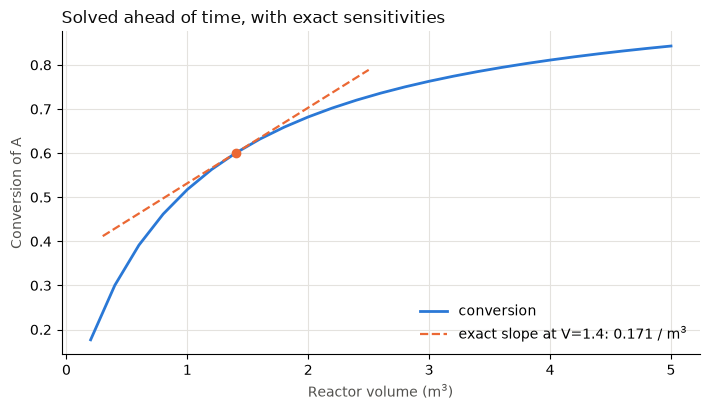

In [15]:
fig, ax = plt.subplots(figsize=(7.2, 4.2))

ax.plot(V, y, color=BLUE, lw=2, zorder=3, label="conversion")

# the exact derivative, drawn as a tangent -- this is what a static page
# cannot get any other way, and what difflow has for free
i = 6
span = 1.1
ax.plot([V[i] - span, V[i] + span],
        [y[i] - span * dy[i], y[i] + span * dy[i]],
        color=ORANGE, lw=1.6, ls="--", zorder=4,
        label=f"exact slope at V={V[i]:.1f}: {dy[i]:.3f} / m$^3$")
ax.plot([V[i]], [y[i]], "o", color=ORANGE, ms=6, zorder=5)

ax.set_xlabel("Reactor volume (m$^3$)", color=INK_SOFT)
ax.set_ylabel("Conversion of A", color=INK_SOFT)
ax.set_title("Solved ahead of time, with exact sensitivities", color=INK, loc="left")
ax.grid(True, color=GRID, lw=0.8)
ax.set_axisbelow(True)
for side in ("top", "right"):
    ax.spines[side].set_visible(False)
ax.legend(frameon=False, loc="lower right")
fig.tight_layout()
plt.show()

The page ships those values and interpolates between them. It is exact *at* the grid
points and only as good as the grid between, which is why the published page says so in
its own footer rather than leaving the reader to discover it.

In [16]:
path = publish(
    build(),
    axes=[axis],
    outputs={"conversion": lambda s: 1.0 - s["out"]["F_A"] / 1.0},
    path="reactor_model.html",
    title="Reactor sizing",
    description="Conversion of A against reactor volume, solved with difflow.",
)
page = path.read_text()

print(f"{path.name}: {len(page):,} bytes, self-contained")
print(f"external resources: {page.count('<script src') + page.count('<link ')}")

reactor_model.html: 10,761 bytes, self-contained
external resources: 0


No server, no Python, no CDN — so nothing to rot, which matters for something attached to
a paper that has to outlive its hosting. Open `reactor_model.html` in any browser to drag
the slider.

## Summary

One flowsheet, six representations, all giving the same answer:

| Representation | What it is for | What it costs |
|---|---|---|
| Python with a callable rate law | anything at all | cannot be saved, shown, or shared |
| `mass_action_kinetics` | the same model as a table | mass-action forms only |
| `catalog()` | a tool asking what a unit takes | derived, so never stale |
| `serialize` JSON | saving, diffing, sending | refuses callables outright |
| `codegen` script | reading and editing by hand | none — it is ordinary code |
| `gui` editor | seeing and adjusting, with a real solver | needs difflow installed |
| `publish` page | a reader with nothing installed | fixed topology, interpolated grid |

The dividing line runs through the rate law. Once it is data rather than code, every row
below it becomes possible, and the last one — a model that opens with nothing installed —
is what a published result actually needs.

Two honest limits. `publish` can vary only what its axes name, so it is a *result*, not a
simulator; use the editor or the generated script when you need the real thing. And both
file formats carry `IdealThermo` only, so a flowsheet using a cubic EOS has to be handed
its thermo back on load with `extras=`.